In [172]:
# Installation automatique des dépendances requises dans le noyau Jupyter actuel
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.


# 📊 Étape 3 : Visualisation Multidimensionnelle

Cette étape correspond au troisième chapitre du cours. L'objectif est de concevoir des représentations visuelles premium pour identifier des tendances et insights clés à l'aide de différents outils de bisualisation.

### 1. Préparation de l'environnement

In [173]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("Librairies de visualisation prêtes !")

Librairies de visualisation prêtes !


### 2. Chargement du dataset enrichi

In [174]:
df = pd.read_csv('../data/processed/cleaned_data_sample.csv')
df.head()

,Date,Booking ID,Booking Status,Customer ID,Vehicle Type,Pickup Location,Drop Location,Cancelled Rides by Customer,Reason for cancelling by Customer,Cancelled Rides by Driver,Driver Cancellation Reason,Incomplete Rides,Incomplete Rides Reason,Booking Value,Ride Distance,Driver Ratings,Customer Rating,Payment Method,CTAT,VTAT
0,2024-01-01 00:19:34,"""CNR4352144""",Completed,"""CID8362794""",Bike,Udyog Vihar,Ambience Mall,NaN,NaN,NaN,NaN,NaN,NaN,854.654113,67.620461,4.8,4.8,Cash,44.895797,9.806886
1,2024-01-01 01:35:18,"""CNR9147645""",Completed,"""CID8300238""",Go Mini,Basai Dhankot,Madipur,NaN,NaN,NaN,NaN,NaN,NaN,433.490494,46.696345,4.2,4.1,Uber Wallet,29.493902,15.089018
2,2024-01-01 01:37:50,"""CNR1009222""",Cancelled by Driver,"""CID2030746""",Go Sedan,Tughlakabad,Greater Kailash,NaN,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2024-01-01 01:48:03,"""CNR2740479""",Cancelled by Driver,"""CID3231181""",Auto,Palam Vihar,Kherki Daula Toll,NaN,NaN,1.0,Personal & Car related issues,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2024-01-01 01:49:56,"""CNR7650148""",Cancelled by Driver,"""CID3381661""",Go Sedan,Narsinghpur,Pulbangash,NaN,NaN,1.0,More than permitted people in there,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### 3. Tracés et analyses graphiques

Note : On utilisera uniquement les enregistrements où le prix de la course n'est pas nul pendant toutes les visualisations (on les triera plus proprement dans la section 4).

#### A. Évolution des tendances dans le temps

On commence par étudier l'évolution temporelle des prix en fonction de la période de l'année.

([<matplotlib.axis.XTick at 0x2122a1d4410>,
 [Text(0, 0, '2024-01-01 00:19:34'),
  Text(10, 0, '2024-02-05 08:58:10'),
  Text(20, 0, '2024-03-12 14:19:57'),
  Text(30, 0, '2024-04-16 21:03:52'),
  Text(40, 0, '2024-05-22 22:01:11'),
  Text(50, 0, '2024-06-27 16:52:35'),
  Text(60, 0, '2024-08-01 20:39:22'),
  Text(70, 0, '2024-09-07 12:03:15'),
  Text(80, 0, '2024-10-13 08:48:35'),
  Text(90, 0, '2024-11-17 21:44:58'),
  Text(100, 0, '2024-12-23 17:11:42')])

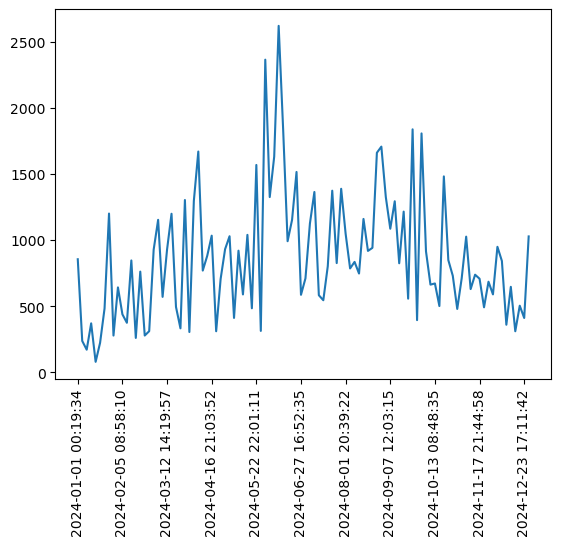

In [175]:
# On fait avec seulement un faible échantillon des dates pour que ce soit lisible (et que ça mette pas cent ans à charger)
# On utilise exclusivement les enregistrements sans null pendant les visualisations
valeurs_nulles = df["Payment Method"].notna()
df = df[valeurs_nulles]

plt.plot(df["Date"][::1000], df["Booking Value"][::1000])
plt.xticks(np.arange(0, len(df["Booking Value"][::1000]), 10), rotation=90)

On peut très vaguement distinguer une tendance où les prix évoluent en fonction du mois de l'année pour être plus élevés en été. On vérifiera cette tendance en étudiant la moyenne de Booking Value en fonction du mois (avec un groupby). La tendance semble se confirmer.

In [176]:
df["Date"] = pd.to_datetime(df["Date"])
mois = df["Date"].map(lambda x : x.month)
df.groupby(mois)["Booking Value"].mean()

Date
1      367.035866
2      501.855086
3      670.340027
4      844.894716
5      992.280837
6     1096.231942
7     1170.650938
8     1171.041115
9     1099.080607
10     987.944078
11     835.673540
12     672.922492
Name: Booking Value, dtype: float64

#### B. Carte de chaleur des corrélations

On va maintenant étudier les corrélations (au sens du coefficient de Pearson) entre les différentes variables numériques, grâce à la fonction corr() de Pandas. On affiche la matrice de corrélations avec une heatmap via la bibliothèque Seaborn. Cette matrice semble indiquer une forte corrélation entre le prix de la course et la distance parcourue, et une encore plus forte avec le temps de la course (Avg CTAT).

<Axes: >

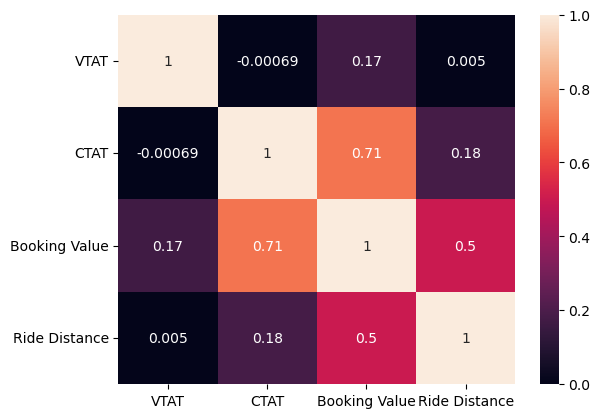

In [177]:
numerical_columns = ["VTAT", "CTAT", "Booking Value", "Ride Distance"]
correlation = df[numerical_columns].corr()
sns.heatmap(correlation, annot=True)

#### C. Nuage de points bivarié

On va également étudier les corrélations entre ces variables via des nuages de points pour s'en faire une idée plus précise. On utilisera pour ça la fonction pairplot() de Seaborn. On peut bel et bien voir les mêmes tendances apparaître entre la variable Booking Value et les variables Ride Distance et Avg CTAT.

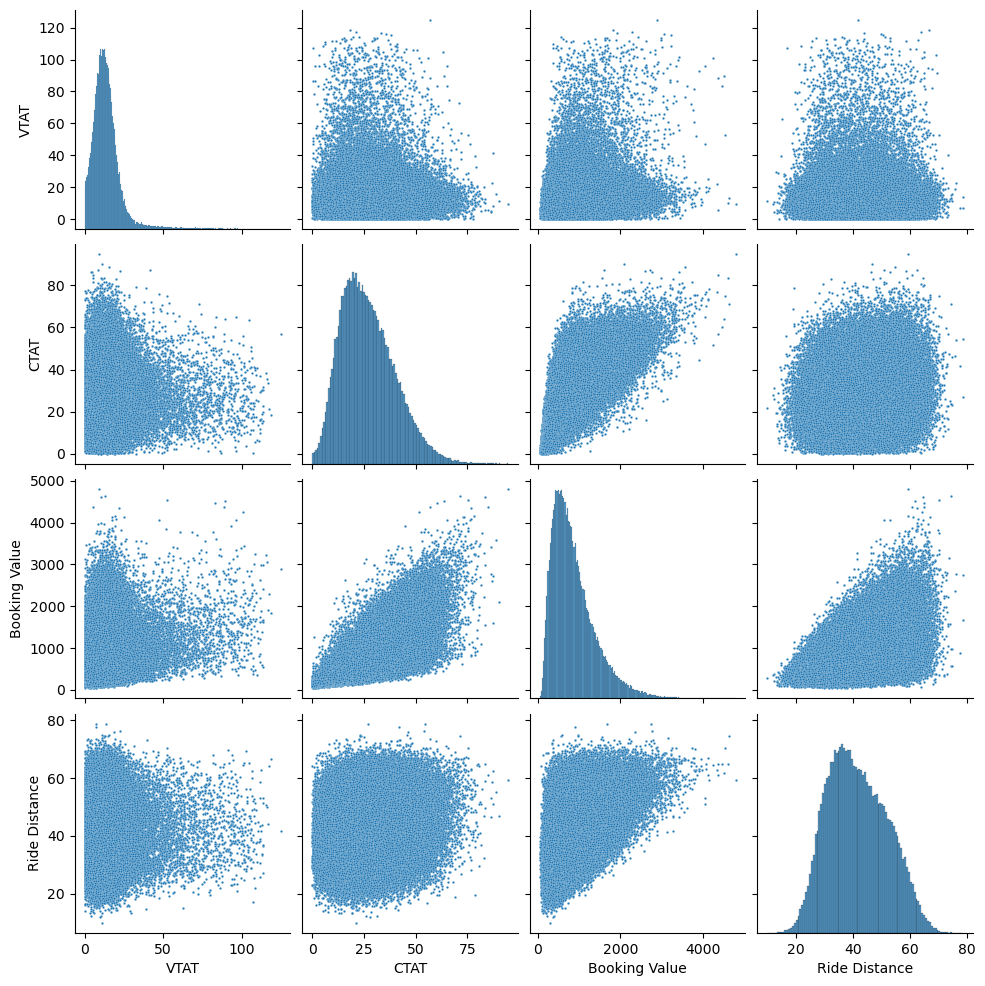

In [178]:
sns.pairplot(df[["VTAT","CTAT","Booking Value","Ride Distance"]], plot_kws={"s": 3})